In [1]:
import pandas as pd #Reading datasets,Handling tables/data,Cleaning data,Analyzing data
import numpy as np #NumPy is used for:Numerical operations,Arrays,Mathematical calculations
import matplotlib.pyplot as plt #Matplotlib is a visualization library.
import seaborn as sns #visualisation loibrary For EDA and professional-looking visualizations.

# Machine Learning libraries
from sklearn.model_selection import train_test_split#It divides dataset into:Training data,Testing data
from sklearn.preprocessing import LabelEncoder #To convert categorical/text data into numbers.
from sklearn.ensemble import RandomForestClassifier #It is a Machine Learning classification algorithm.It predicts:

#Selected or rejected candidate
#Yes or No output
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("AI_Resume_Screening 2.csv")

In [3]:
data.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


DATA UNDERSTANDING

In [4]:
data.shape

(1000, 11)

In [5]:
data.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
data.isnull().sum()

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [8]:
data.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


EDA

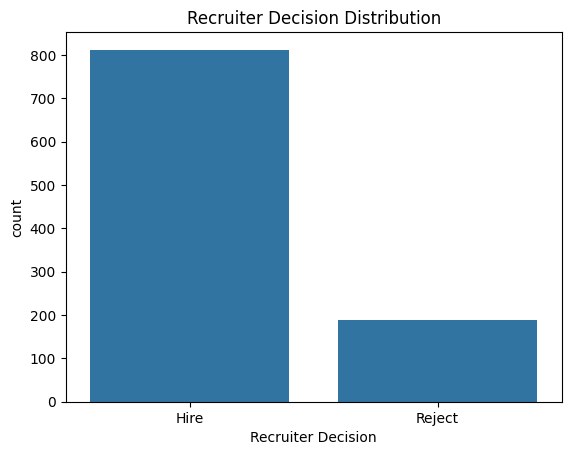

In [9]:
sns.countplot(x='Recruiter Decision', data=data)#This line creates a countplot using Seaborn
#A countplot counts how many times each category appears.
import seaborn as sns
# COUNTPLOT FN : Function used to create category count graphs.
plt.title('Recruiter Decision Distribution')
plt.show()

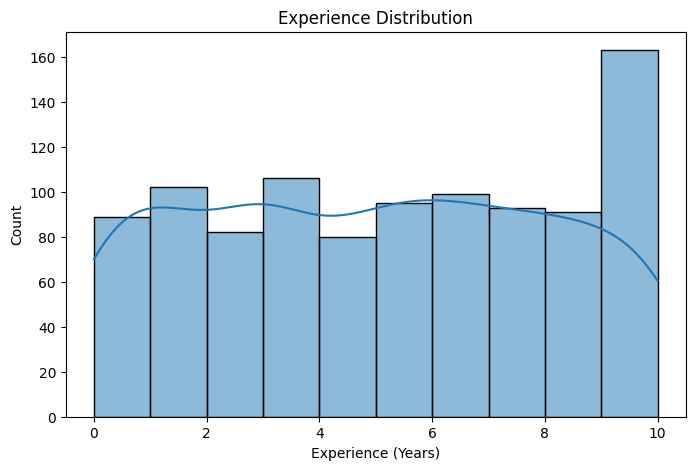

In [10]:
plt.figure(figsize=(8,5)) #CREATE GRAPH WITH FIG SIZE  width 8 and height 5
sns.histplot(data['Experience (Years)'], bins=10, kde=True) #Creates histogram graph.
plt.title('Experience Distribution')
plt.show()

#It shows:How experience is distributed , Whether most candidates are:Freshers , Mid-level , Experienced

AI SCORE DISTRIBUTION

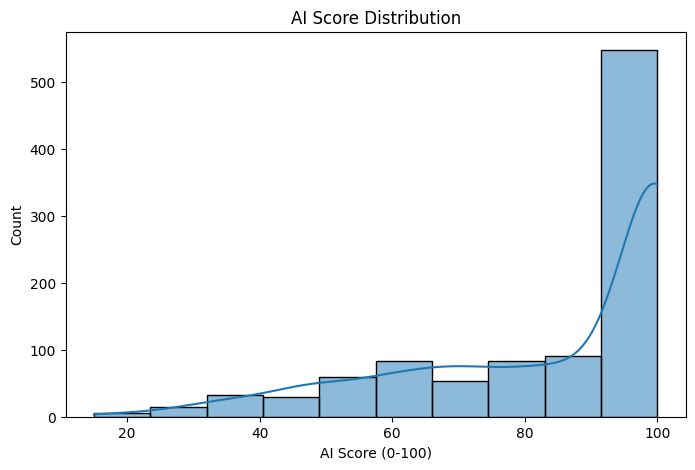

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data['AI Score (0-100)'], bins=10, kde=True)
plt.title('AI Score Distribution')
plt.show()

EDUCATION DISTRIBUTION


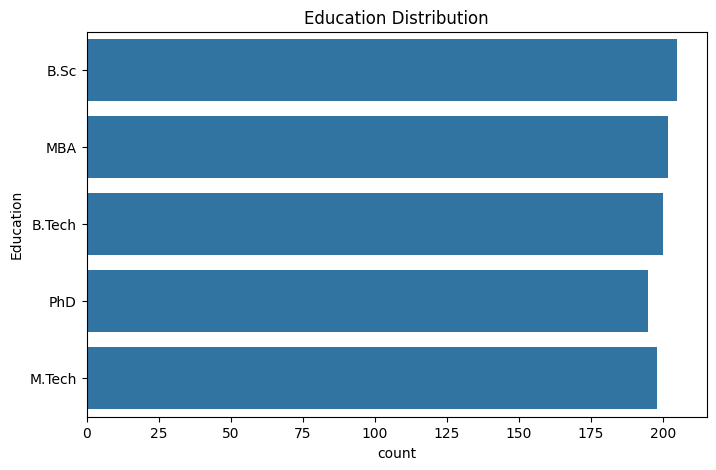

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(y='Education', data=data)
plt.title('Education Distribution')
plt.show()

DATA PREPROCESSING

In [13]:
data['Certifications'].fillna('No Certification', inplace=True)#replacing null values with text

In [14]:
data.isnull().sum() #varifying

Resume_ID                 0
Name                      0
Skills                    0
Experience (Years)        0
Education                 0
Certifications            0
Job Role                  0
Recruiter Decision        0
Salary Expectation ($)    0
Projects Count            0
AI Score (0-100)          0
dtype: int64

In [15]:
data.drop(['Resume_ID', 'Name'], axis=1, inplace=True) #removing unecessary columns

In [16]:
data.columns

Index(['Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role', 'Recruiter Decision', 'Salary Expectation ($)',
       'Projects Count', 'AI Score (0-100)'],
      dtype='object')

Encoding Categorical Columns 🔢

In [17]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [18]:
data['Skills'] = encoder.fit_transform(data['Skills'])

In [19]:
data['Education'] = encoder.fit_transform(data['Education'])
# Selects Education column->fit:Learns categories->Converts them into numbers.

In [20]:
data['Certifications'] = encoder.fit_transform(data['Certifications'])

In [21]:
data['Job Role'] = encoder.fit_transform(data['Job Role'])

In [22]:
data['Recruiter Decision'] = encoder.fit_transform(data['Recruiter Decision'])

In [23]:
data.head()

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,226,10,0,3,0,0,104895,8,100
1,32,10,3,2,2,0,113002,1,100
2,46,1,3,1,1,0,71766,7,70
3,152,7,1,0,0,0,46848,0,95
4,221,4,4,3,3,0,87441,9,100


Separate Features and Target

In [24]:
X = data.drop('Recruiter Decision', axis=1)#Stores input features,drop target columns bcz We should not use output column as input.

In [25]:
y = data['Recruiter Decision']#Stores target/output column , This is what model will predict.

TRAIN TEST SPLIT

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 8)
(200, 8)
(800,)
(200,)


BUILDING FIRST ML MODEL
1.LOGISTIC REGRESSION

In [28]:
from sklearn.linear_model import LogisticRegression#importing
lr = LogisticRegression() #creating a model

In [29]:
lr.fit(X_train, y_train) #training the model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred_lr = lr.predict(X_test)#make predictions

In [31]:
lg_cc=accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:",lg_cc)

Logistic Regression Accuracy: 0.92


2.DECISION TREE


In [32]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)#Creates a Decision Tree model.

In [33]:
dt.fit(X_train, y_train)#learns patterns from training data

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
y_pred_dt = dt.predict(X_test)#Predicts Recruiter Decision on test data.

In [35]:
dt_cc=accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:",dt_cc)

Decision Tree Accuracy: 1.0


3.RANDOM FOREST

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

In [37]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred_rf = rf.predict(X_test)

In [39]:
rf_cc= accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:",rf_cc)

Random Forest Accuracy: 1.0


Hyperparameter Tuning for Decision Tree

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
#Create Parameter Grid
param_grid_dt = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
#min_samples_split : Minimum samples required to split a node.
#max_depth : Controls how deep the tree can grow.
#criterion : How the tree decides splits:gini,entropy

In [42]:
#run gridsearchcv
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train, y_train)
#cv=5 : 5-fold cross validation.
#scoring='accuracy':Selects the model with the highest accuracy.

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [43]:
#best parameter
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [44]:
dc_ccc= grid_dt.best_score_
print("Best Cross Validation Accuracy:",dc_ccc)

Best Cross Validation Accuracy: 1.0


Hyperparameter Tuning for Logistic Regression

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
#C:Controls regularization strength.
#solver:Optimization algorithm used by Logistic Regression.

In [47]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [48]:
print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}


In [49]:
lg_ccc= grid_lr.best_score_
print("Best Cross Validation Accuracy:",lg_ccc)

Best Cross Validation Accuracy: 0.9974999999999999


Hyperparameter Tuning for Random Forest

In [50]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [51]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [52]:
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [53]:
rf_ccc= grid_rf.best_score_
print("Best Cross Validation Accuracy:",rf_ccc)

Best Cross Validation Accuracy: 1.0


Feature Importance Analysis
This is a very good addition to an ML project because it answers:
Which factors most influence recruiter decisions

In [54]:
#comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest',
              'Tuned Decision Tree',
              'Tuned Logistic Regression',
              'Tuned Random Forest'],
    
    'Accuracy': [0.92,
                 1.00,
                 1.00,
                 1.00,
                 0.9975,
                 1.00]
})

print(comparison)

                       Model  Accuracy
0        Logistic Regression    0.9200
1              Decision Tree    1.0000
2              Random Forest    1.0000
3        Tuned Decision Tree    1.0000
4  Tuned Logistic Regression    0.9975
5        Tuned Random Forest    1.0000


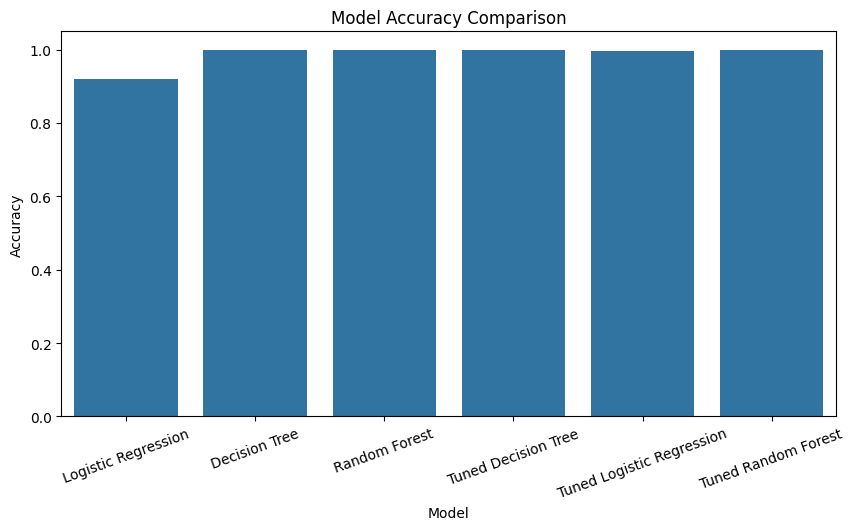

In [55]:
#accuracy comparison plot
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20)
plt.show()

Feature Importance Analysis : 
Since Random Forest is the final model, let's find out which features influenced the recruiter decision the most.


In [56]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                  Feature  Importance
7        AI Score (0-100)    0.650045
1      Experience (Years)    0.211973
6          Projects Count    0.076600
5  Salary Expectation ($)    0.021088
0                  Skills    0.020668
3          Certifications    0.008680
2               Education    0.005643
4                Job Role    0.005302


Plot Feature Importance

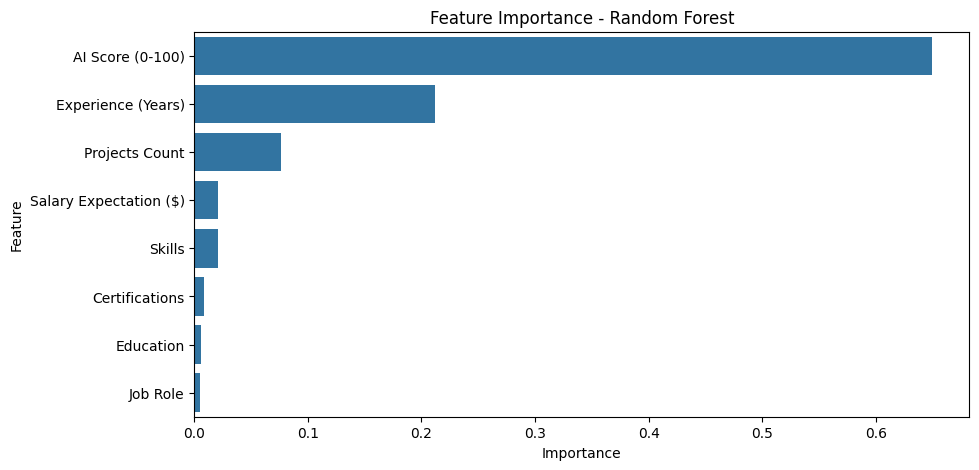

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.show()

Save Predictions

In [58]:
results = X_test.copy()

results['Actual Decision'] = y_test
results['Predicted Decision'] = y_pred_rf

print(results.head())

     Skills  Experience (Years)  Education  Certifications  Job Role  \
521     112                   9          0               3         0   
737      15                   6          3               0         1   
740     172                   5          3               0         0   
660      70                   8          2               2         3   
411      25                   4          4               3         1   

     Salary Expectation ($)  Projects Count  AI Score (0-100)  \
521                  108379              10               100   
737                   56096               8               100   
740                   77117               6               100   
660                   50950               8               100   
411                   87051               0                50   

     Actual Decision  Predicted Decision  
521                0                   0  
737                0                   0  
740                0                   0  
660 

Export Results to Excel

In [59]:
results.to_excel(
    "Resume_Screening_Results.xlsx",
    index=False
)

print("Excel file exported successfully!")

Excel file exported successfully!


This Excel file will be used for your dashboard.

In [60]:
import pickle

pickle.dump(rf, open('resume_model.pkl', 'wb'))

print("Model saved successfully!")
#Your Random Forest model currently exists only in memory.When you close Jupyter Notebook, it disappears.
#resume_model.pkl saves the trained model so that Streamlit can load it later and make predictions.

Model saved successfully!


In [61]:
print(df['Recruiter Decision'].value_counts())

NameError: name 'df' is not defined